<a href="https://colab.research.google.com/github/caiohenry-jpg/CalculoNumerico/blob/main/Atividade1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PARTE A - truncamento e arredondamento

valor  n   truncado     arredondado  Ea trunc   Ea arred   E% arred
------------------------------------------------------------------------
x1     0   3.000000     3.000000     1.42e-01   1.42e-01   4.5070
x1     1   3.100000     3.100000     4.16e-02   4.16e-02   1.3239
x1     2   3.140000     3.140000     1.59e-03   1.59e-03   0.0507
x1     3   3.141000     3.142000     5.93e-04   4.07e-04   0.0130
x1     4   3.141500     3.141600     9.27e-05   7.35e-06   0.0002

x2     0   98.000000    99.000000    7.65e-01   2.35e-01   0.2375
x2     1   98.700000    98.800000    6.54e-02   3.46e-02   0.0350
x2     2   98.760000    98.770000    5.43e-03   4.57e-03   0.0046
x2     3   98.765000    98.765000    4.30e-04   4.30e-04   0.0004
x2     4   98.765400    98.765400    3.00e-05   3.00e-05   0.0000

x3     0   0.000000     0.000000     4.99e-03   4.99e-03   100.0000
x3     1   0.000000     0.000000     4.99e-03   4.99e-03   100.0000
x3     2   0.000000  

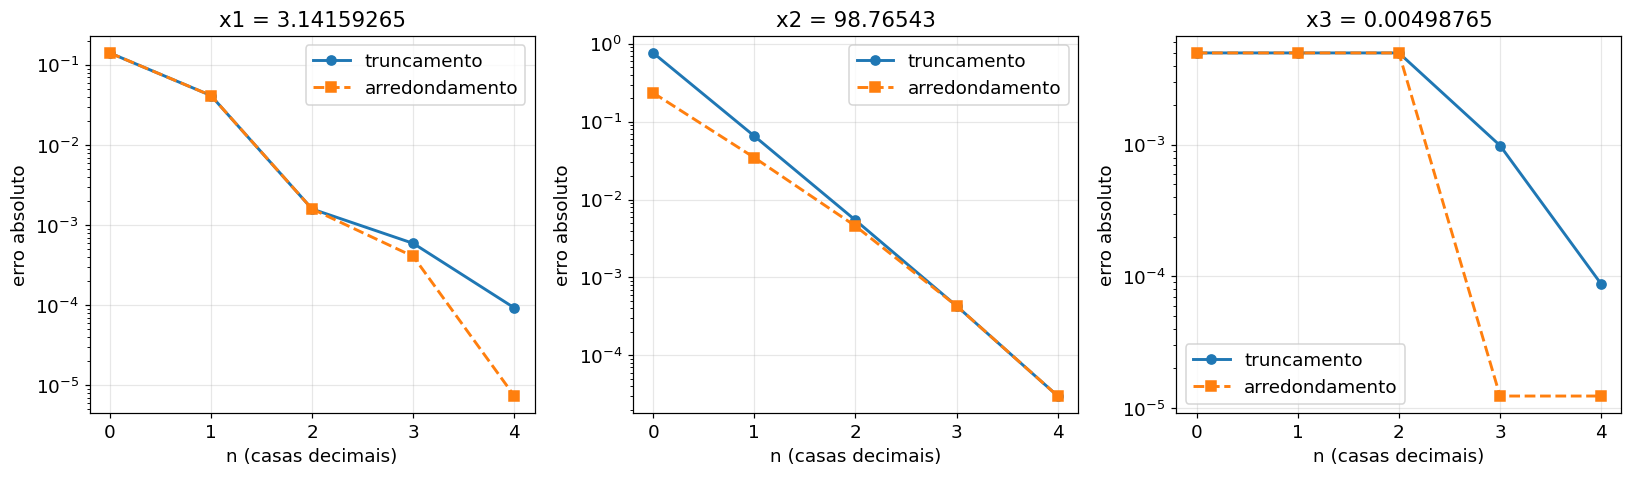

casos em que arredondar errou MAIS que truncar: 0

PARTE B - pressao arterial

media de referencia = 121.1200 mmHg

serie            media     min     max    amplitude  desvio   Ea      E%
------------------------------------------------------------------------------
originais        121.120   119.8   122.4      2.6    0.8337   0.000   0.0000
arred. inteiro   121.100   120.0   122.0      2.0    0.8756   0.020   0.0165
trunc. inteiro   120.700   119.0   122.0      3.0    0.9487   0.420   0.3468
arred. 1 casa    121.120   119.8   122.4      2.6    0.8337   0.000   0.0000


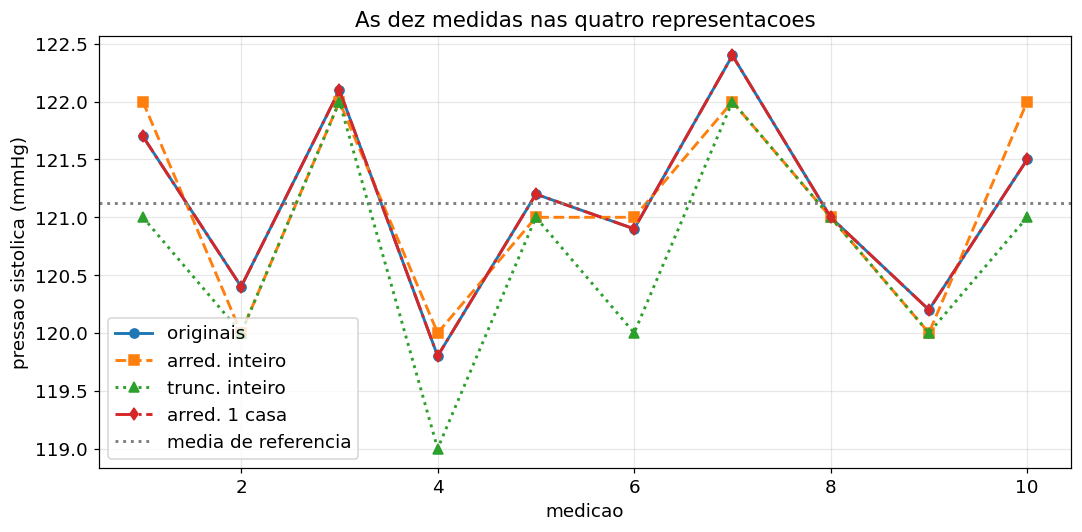

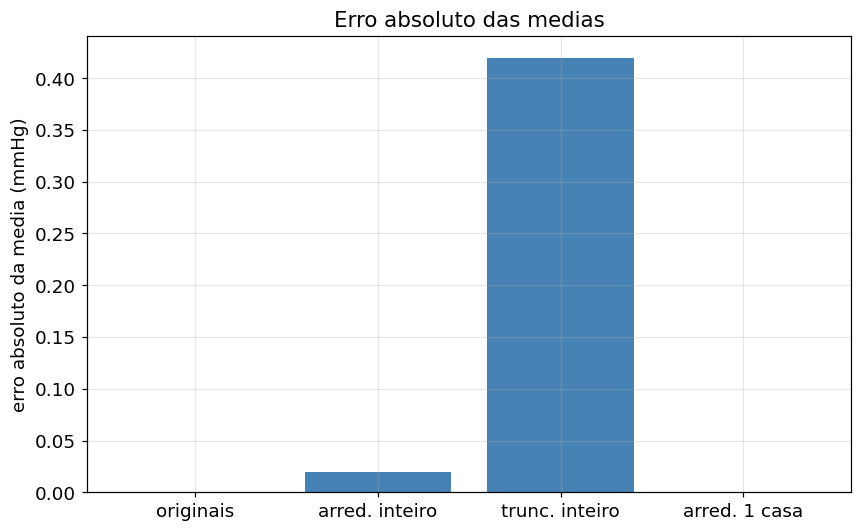

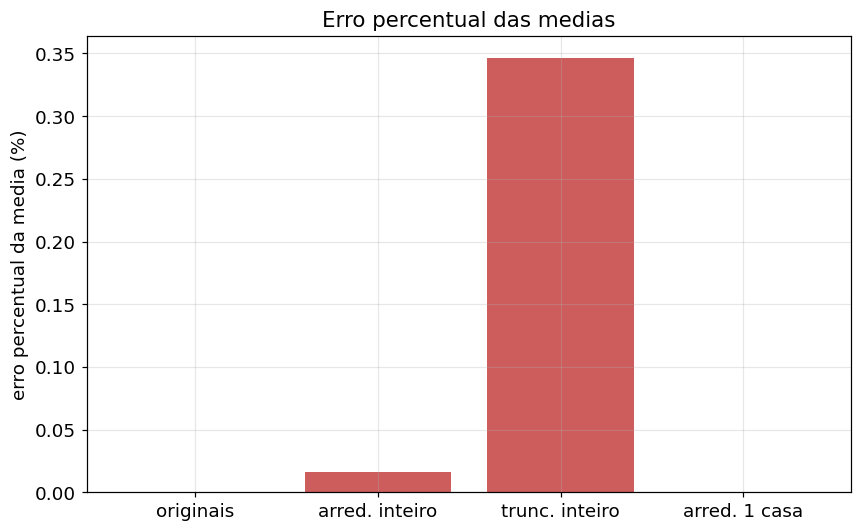

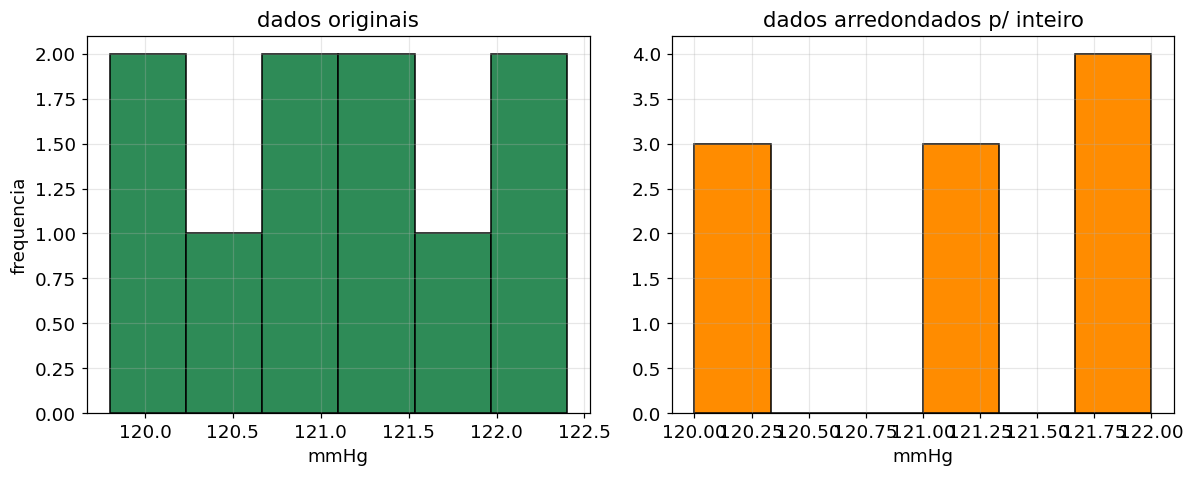


PARTE C - vazao no tubo

Q de referencia = 2.757421e-07 m3/s

cenario                        Q (m3/s)       E%
-------------------------------------------------------
todos os valores dados         2.7574e-07     0.00
r arredondado 1 casa           2.7574e-07     0.00
r truncado 1 casa              2.7574e-07     0.00
mu arredondada 3 casas         2.4127e-07    12.50
mu truncada 3 casas            3.2170e-07    16.67
dp arredondado centena         2.7574e-07     0.00
dp truncado centena            2.7574e-07     0.00
tudo arredondado               2.4127e-07    12.50
tudo truncado                  3.2170e-07    16.67


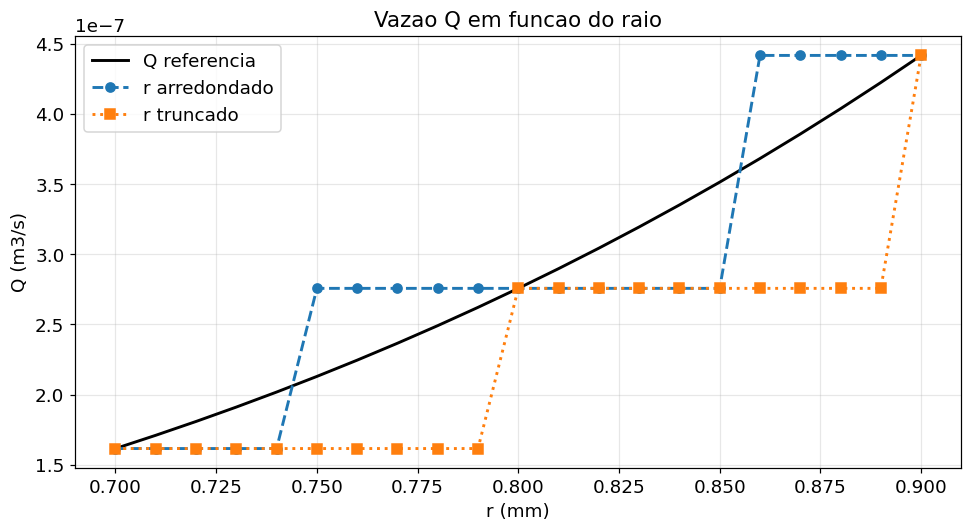

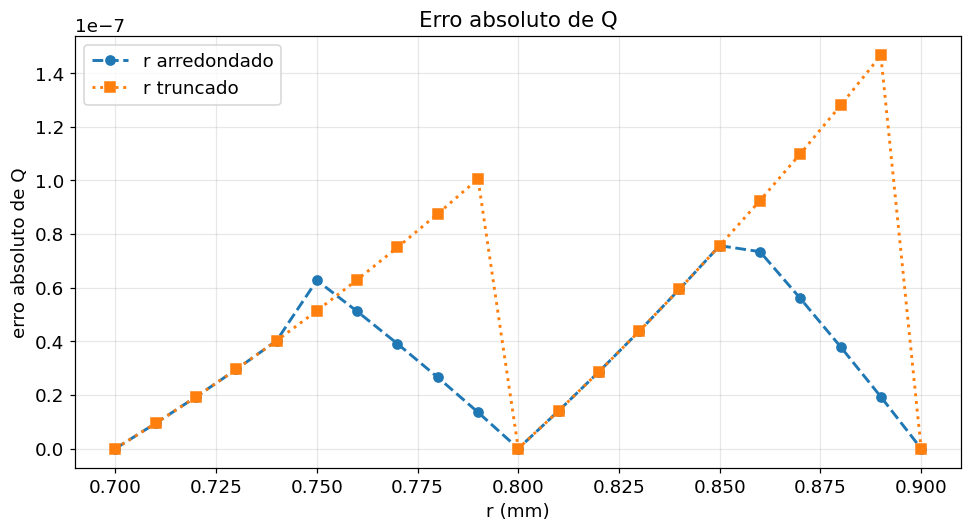

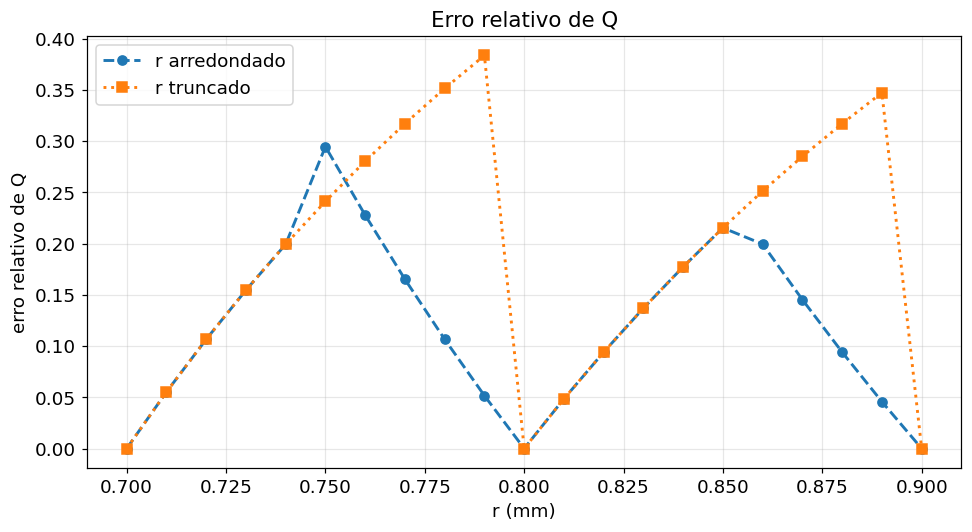

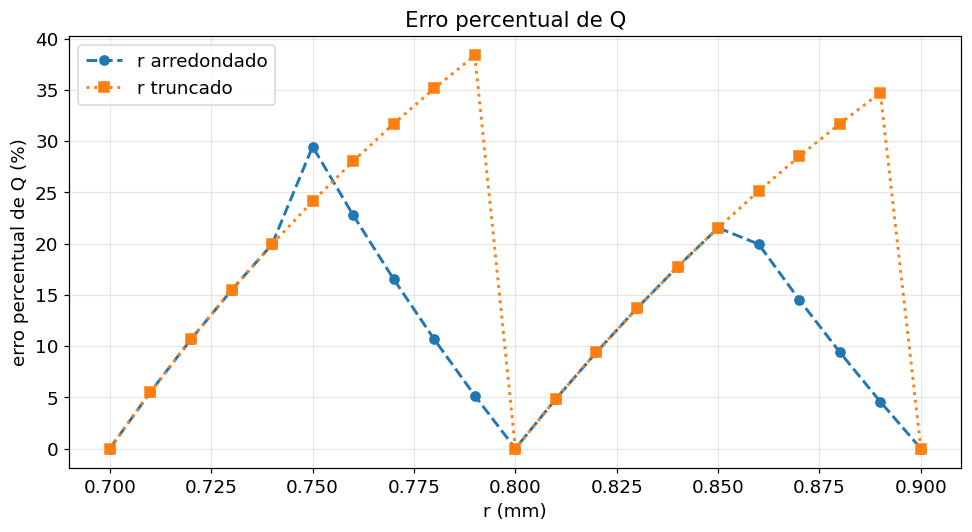


PARTE D - nanocateter

Q com r = 50 nm: 3.506242e-19 m3/s

dr (nm)   erro % real   aprox 4*dr/r
----------------------------------------
  0.1         0.80          0.80
  1.0         8.24          8.00
  2.5        21.55         20.00
  5.0        46.41         40.00


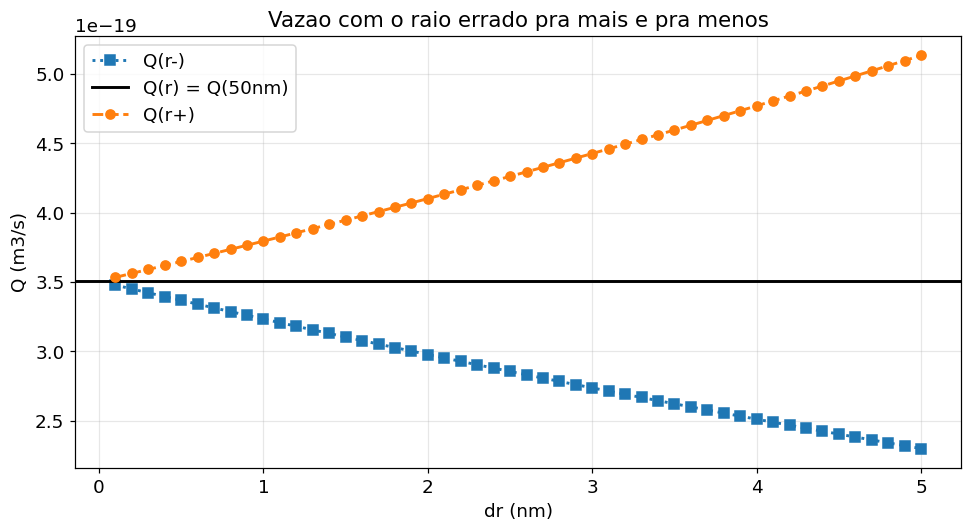

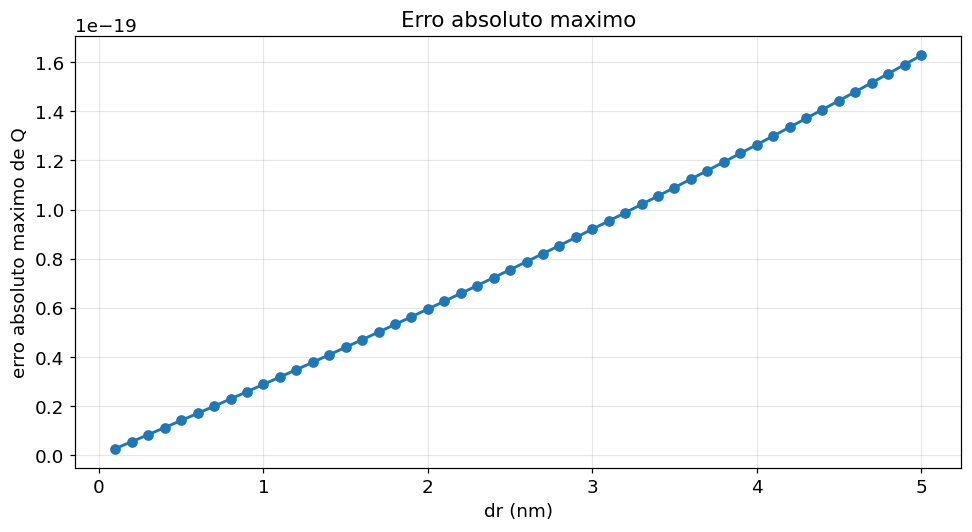

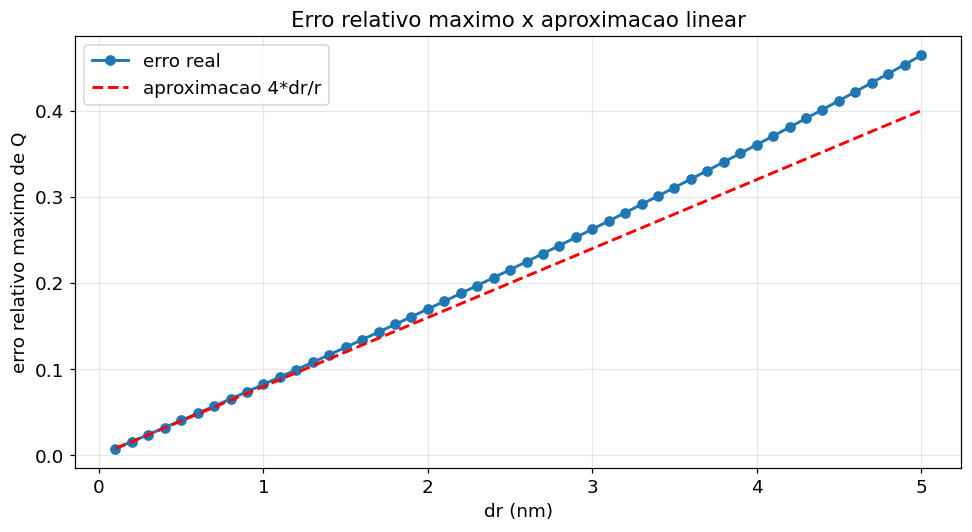

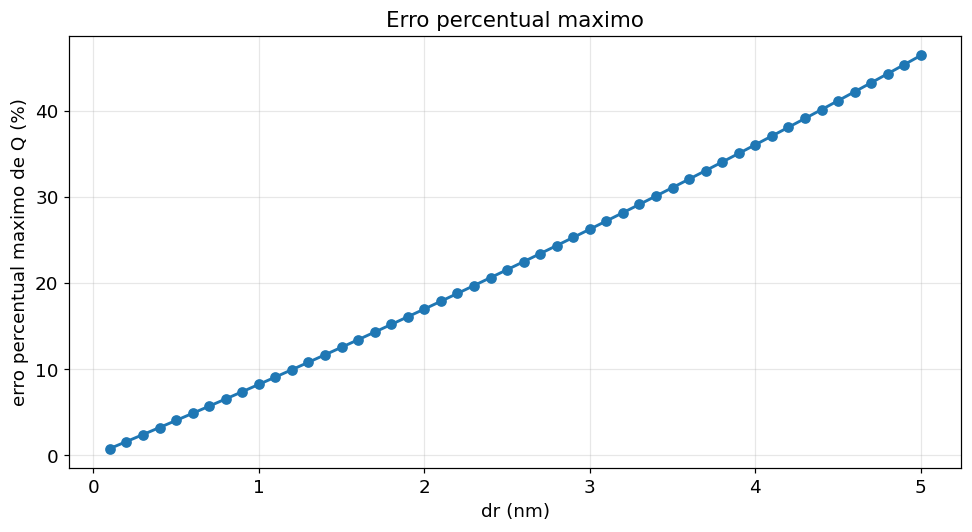


--- float32 x float64 ---
r^4 em float32: 6.25000040e-30
r^4 em float64: 6.25000000e-30
Q em float32:   3.50624232e-19
Q em float64:   3.50624180e-19
diferenca absoluta: 5.2286e-26
diferenca relativa: 1.4912e-07
eps do float32: 1.1921e-07
eps do float64: 2.2204e-16

dr/r        delta1 (direto)   delta2 (formula)   diferenca
--------------------------------------------------------------
1e-01   4.6410000000e-01   4.6410000000e-01   1.79e-15
1e-02   4.0604010000e-02   4.0604010000e-02   8.89e-15
1e-04   4.0006000400e-04   4.0006000400e-04   3.24e-14
1e-06   4.0000060000e-06   4.0000059998e-06   6.53e-11
1e-08   4.0000000603e-08   4.0000000423e-08   4.50e-09
1e-10   4.0000003762e-10   4.0000003310e-10   1.13e-08
1e-12   4.0000388262e-12   4.0003556023e-12   7.92e-05
1e-14   4.0235208077e-14   3.9968028887e-14   6.68e-03


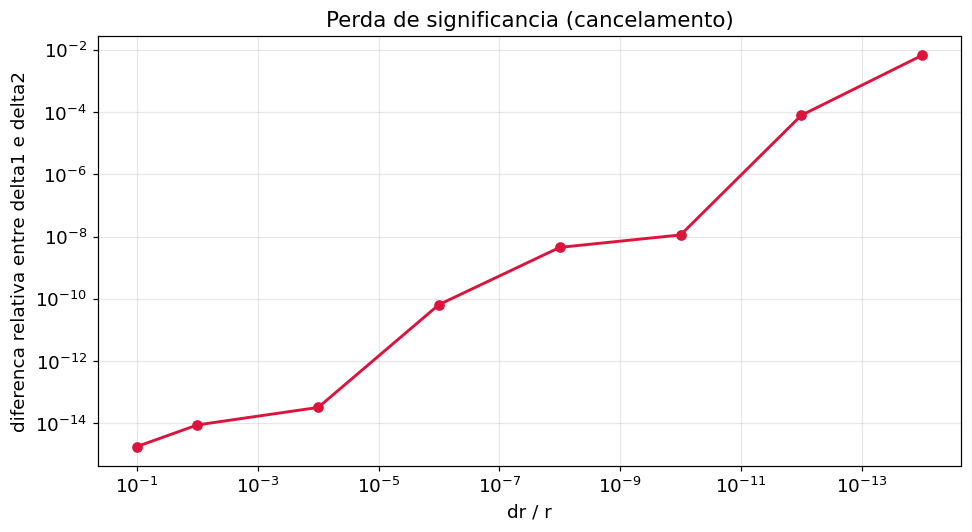


PARTE E - quadro de resultados


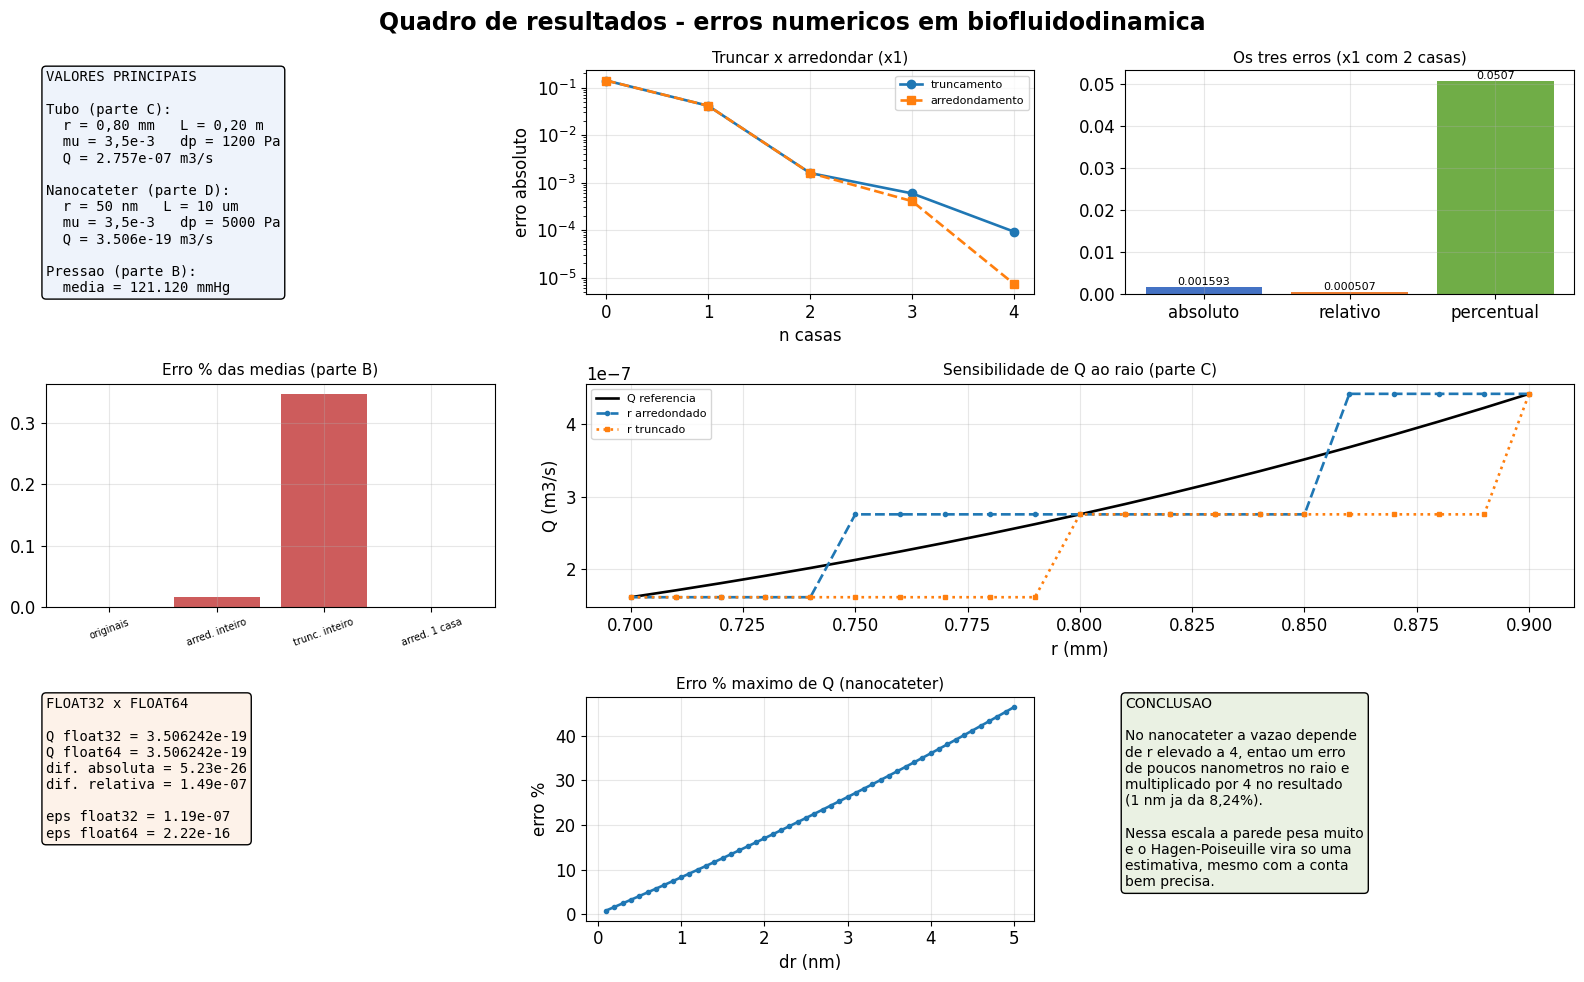


GIF
GIF salvo com 40 quadros

CONCLUSAO

Fazendo essa atividade deu pra entender que erro numerico nao e so "perder
casa decimal" - depende de como o erro entra na conta.

Na parte A vi que arredondar e sempre igual ou melhor que truncar, porque
truncar erra sempre pro mesmo lado. E no x3, que e um numero pequeno, o erro
absoluto parecia minusculo mas o relativo deu 100%: por isso nao da pra olhar
so um tipo de erro.

Na parte B esse vies do truncamento apareceu de novo: como todo mundo foi
cortado pra baixo, a media inteira desceu (0,347% de erro contra 0,0165% do
arredondamento). E aprendi que preservar a media nao significa preservar a
variabilidade - o desvio padrao e a amplitude mudaram bastante.

As partes C e D foram as que mais me chamaram atencao. Como Q depende de r^4,
o erro relativo do raio e multiplicado por 4 na vazao. No tubo, um decimo de
milimetro virava 30% de erro; no nanocateter, 1 nm (que e so 2% do raio) ja da
8,24%. Tambem vi que a formula aproximada 4*dr/r func

In [5]:
# Atividade I - Calculo Numerico
# Erros numericos em biofluidodinamica
# Caio Domingues - RA 180374   Pedro Feris - RA  178198
# Divisao das tarefas: Trabalho realizado em conjunto

import os
import math
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import io

# pasta onde vou salvar os graficos
os.makedirs("saidas", exist_ok=True)


# ---------------------------------------------------------------
# funcoes que vou usar na atividade toda
# ---------------------------------------------------------------

def truncar(x, n):
    # corta os numeros depois da casa n, sem arredondar
    # ex: truncar(3.148, 2) = 3.14  (o 8 e simplesmente jogado fora)
    fator = 10 ** n
    return math.trunc(x * fator) / fator


def erro_absoluto(x, aprox):
    # o quanto errei, na unidade da grandeza
    return abs(x - aprox)


def erro_relativo(x, aprox):
    # o erro comparado com o tamanho do numero
    return abs(x - aprox) / abs(x)


def erro_percentual(x, aprox):
    # mesma coisa que o relativo, so que em %
    return 100 * erro_relativo(x, aprox)


def vazao(r, dp, mu, L):
    # Hagen-Poiseuille: Q = pi * r^4 * dp / (8 * mu * L)
    # tudo em unidades do SI (r e L em metros)
    return (math.pi * r ** 4 * dp) / (8 * mu * L)


# ===============================================================
# PARTE A - truncamento e arredondamento
# ===============================================================
print("=" * 60)
print("PARTE A - truncamento e arredondamento")
print("=" * 60)

x1 = 3.14159265
x2 = 98.76543
x3 = 0.00498765

valores = [("x1", x1), ("x2", x2), ("x3", x3)]
casas = [0, 1, 2, 3, 4]

# tabela (item 3)
print()
print("valor  n   truncado     arredondado  Ea trunc   Ea arred   E% arred")
print("-" * 72)

for nome, x in valores:
    for n in casas:
        xt = truncar(x, n)
        xa = round(x, n)

        ea_t = erro_absoluto(x, xt)
        ea_a = erro_absoluto(x, xa)
        ep_a = erro_percentual(x, xa)

        print("%-6s %d   %-12.6f %-12.6f %-10.2e %-10.2e %.4f"
              % (nome, n, xt, xa, ea_t, ea_a, ep_a))
    print()

# grafico do item 4: Ea x n em escala log
plt.figure(figsize=(15, 4.5))

for i in range(3):
    nome, x = valores[i]

    erros_trunc = []
    erros_arred = []
    for n in casas:
        et = erro_absoluto(x, truncar(x, n))
        ea = erro_absoluto(x, round(x, n))
        # se der zero o log quebra, entao troco por um numero bem pequeno
        if et == 0:
            et = 1e-16
        if ea == 0:
            ea = 1e-16
        erros_trunc.append(et)
        erros_arred.append(ea)

    plt.subplot(1, 3, i + 1)
    plt.semilogy(casas, erros_trunc, "o-", label="truncamento")
    plt.semilogy(casas, erros_arred, "s--", label="arredondamento")
    plt.title(nome + " = " + str(x))
    plt.xlabel("n (casas decimais)")
    plt.ylabel("erro absoluto")
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.savefig("saidas/A_erro_absoluto.png", dpi=150)
plt.savefig("saidas/A_erro_absoluto.pdf")
plt.show()

# item 5: conferindo se arredondar sempre erra menos
maior = 0
for nome, x in valores:
    for n in casas:
        if erro_absoluto(x, round(x, n)) > erro_absoluto(x, truncar(x, n)):
            maior = maior + 1

print("casos em que arredondar errou MAIS que truncar:", maior)

# RESPOSTA (item 5):
# Nenhum caso. Arredondar sempre errou igual ou menos.
# Isso acontece porque o arredondamento pega o valor mais perto de x, entao
# no maximo erra metade da ultima casa. Ja o truncamento corta sempre pro
# mesmo lado, entao pode errar a casa inteira - o dobro no pior caso.
# Os dois empatam quando o primeiro numero cortado e menor que 5, porque ai
# arredondar da no mesmo que cortar (ex: x1 com n = 0, 1 e 2).
# Reparei tambem que no x3, que e bem pequeno, com n = 0, 1 e 2 o resultado
# vira zero e o erro relativo da 100%. Numero pequeno precisa de mais casas.


# ===============================================================
# PARTE B - medidas de pressao arterial
# ===============================================================
print()
print("=" * 60)
print("PARTE B - pressao arterial")
print("=" * 60)

dados = [121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5]

# a referencia e a media usando todos os numeros, sem arredondar nada
media_ref = sum(dados) / len(dados)
print()
print("media de referencia = %.4f mmHg" % media_ref)

# as 4 series pedidas
originais = dados
arred_int = [round(v) for v in dados]
trunc_int = [truncar(v, 0) for v in dados]
arred_1casa = [round(v, 1) for v in dados]

series = [("originais", originais),
          ("arred. inteiro", arred_int),
          ("trunc. inteiro", trunc_int),
          ("arred. 1 casa", arred_1casa)]

print()
print("serie            media     min     max    amplitude  desvio   Ea      E%")
print("-" * 78)

# guardo os erros pra usar nos graficos de barra
nomes_series = []
erros_abs = []
erros_pct = []

for nome, s in series:
    media = np.mean(s)
    minimo = min(s)
    maximo = max(s)
    amplitude = maximo - minimo
    desvio = np.std(s, ddof=1)   # ddof=1 porque e desvio AMOSTRAL

    ea = erro_absoluto(media_ref, media)
    ep = erro_percentual(media_ref, media)

    print("%-15s %8.3f %7.1f %7.1f %8.1f %9.4f %7.3f %8.4f"
          % (nome, media, minimo, maximo, amplitude, desvio, ea, ep))

    nomes_series.append(nome)
    erros_abs.append(ea)
    erros_pct.append(ep)

# grafico 1 - as dez medidas nas 4 series
plt.figure(figsize=(10, 5))
medicoes = list(range(1, 11))
plt.plot(medicoes, originais, "o-", label="originais")
plt.plot(medicoes, arred_int, "s--", label="arred. inteiro")
plt.plot(medicoes, trunc_int, "^:", label="trunc. inteiro")
plt.plot(medicoes, arred_1casa, "d-.", label="arred. 1 casa")
plt.axhline(media_ref, color="gray", linestyle=":", label="media de referencia")
plt.xlabel("medicao")
plt.ylabel("pressao sistolica (mmHg)")
plt.title("As dez medidas nas quatro representacoes")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("saidas/B1_medicoes.png", dpi=150)
plt.savefig("saidas/B1_medicoes.pdf")
plt.show()

# grafico 2 - erro absoluto das medias
plt.figure(figsize=(8, 5))
plt.bar(nomes_series, erros_abs, color="steelblue")
plt.ylabel("erro absoluto da media (mmHg)")
plt.title("Erro absoluto das medias")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("saidas/B2_erro_absoluto.png", dpi=150)
plt.savefig("saidas/B2_erro_absoluto.pdf")
plt.show()

# grafico 3 - erro percentual das medias
plt.figure(figsize=(8, 5))
plt.bar(nomes_series, erros_pct, color="indianred")
plt.ylabel("erro percentual da media (%)")
plt.title("Erro percentual das medias")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("saidas/B3_erro_percentual.png", dpi=150)
plt.savefig("saidas/B3_erro_percentual.pdf")
plt.show()

# grafico 4 - histogramas
plt.figure(figsize=(11, 4.5))

plt.subplot(1, 2, 1)
plt.hist(originais, bins=6, color="seagreen", edgecolor="black")
plt.title("dados originais")
plt.xlabel("mmHg")
plt.ylabel("frequencia")

plt.subplot(1, 2, 2)
plt.hist(arred_int, bins=6, color="darkorange", edgecolor="black")
plt.title("dados arredondados p/ inteiro")
plt.xlabel("mmHg")

plt.tight_layout()
plt.savefig("saidas/B4_histogramas.png", dpi=150)
plt.savefig("saidas/B4_histogramas.pdf")
plt.show()

# RESPOSTA:
# Pra MEDIA, arredondar pra inteiro quase nao atrapalha: errou so 0,020 mmHg
# (0,0165%). Mas truncar errou 0,420 mmHg (0,347%), que e bem mais. Isso
# acontece porque truncar sempre corta pra baixo, entao o erro nao se
# compensa - ele empurra a media inteira pra baixo.
# Pra VARIABILIDADE nao serve. O desvio padrao mudou de 0,8337 pra 0,8756
# (arredondado) e 0,9487 (truncado), e a amplitude foi de 2,6 pra 2,0 e 3,0.
# Como sao so 10 medidas e elas variam poucos mmHg, arredondar pra inteiro
# mexe demais na dispersao. Da pra ver isso nos histogramas.
# (nao estou fazendo interpretacao medica dos valores)


# ===============================================================
# PARTE C - vazao em tubo de pequeno diametro
# ===============================================================
print()
print("=" * 60)
print("PARTE C - vazao no tubo")
print("=" * 60)

r_mm = 0.80          # mm
L = 0.20             # m
mu = 3.5e-3          # Pa.s
dp = 1200.0          # Pa

r = r_mm / 1000      # converto mm -> m

Q_ref = vazao(r, dp, mu, L)
print()
print("Q de referencia = %.6e m3/s" % Q_ref)

# C.1 - trocando a precisao de cada variavel
print()
print("cenario                        Q (m3/s)       E%")
print("-" * 55)

cenarios = [
    ("todos os valores dados", r_mm, mu, dp),
    ("r arredondado 1 casa", round(r_mm, 1), mu, dp),
    ("r truncado 1 casa", truncar(r_mm, 1), mu, dp),
    ("mu arredondada 3 casas", r_mm, round(mu, 3), dp),
    ("mu truncada 3 casas", r_mm, truncar(mu, 3), dp),
    ("dp arredondado centena", r_mm, mu, round(dp, -2)),
    ("dp truncado centena", r_mm, mu, math.trunc(dp / 100) * 100),
    ("tudo arredondado", round(r_mm, 1), round(mu, 3), round(dp, -2)),
    ("tudo truncado", truncar(r_mm, 1), truncar(mu, 3), math.trunc(dp / 100) * 100),
]

for nome, rr, mm_, dpp in cenarios:
    Q = vazao(rr / 1000, dpp, mm_, L)
    print("%-30s %.4e   %6.2f" % (nome, Q, erro_percentual(Q_ref, Q)))

# OBSERVACAO:
# r = 0,80 mm ja tem 1 casa decimal e dp = 1200 ja e multiplo de 100, entao
# arredondar ou truncar esses dois nao muda nada (erro zero).
# Quem estraga o resultado aqui e o mu, que vira 0,004 ou 0,003 e joga o erro
# pra 12,5% e 16,67%.

# C.2 - variando o raio de 0,70 a 0,90 mm
raios = np.arange(0.70, 0.901, 0.01)

Q_referencia = []
Q_arredondado = []
Q_truncado = []

for raio in raios:
    Q_referencia.append(vazao(raio / 1000, dp, mu, L))
    Q_arredondado.append(vazao(round(raio, 1) / 1000, dp, mu, L))
    Q_truncado.append(vazao(truncar(raio, 1) / 1000, dp, mu, L))

Q_referencia = np.array(Q_referencia)
Q_arredondado = np.array(Q_arredondado)
Q_truncado = np.array(Q_truncado)

# grafico 1 - Q em funcao de r
plt.figure(figsize=(9, 5))
plt.plot(raios, Q_referencia, "k-", label="Q referencia")
plt.plot(raios, Q_arredondado, "o--", label="r arredondado")
plt.plot(raios, Q_truncado, "s:", label="r truncado")
plt.xlabel("r (mm)")
plt.ylabel("Q (m3/s)")
plt.title("Vazao Q em funcao do raio")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("saidas/C1_Q_vs_r.png", dpi=150)
plt.savefig("saidas/C1_Q_vs_r.pdf")
plt.show()

# graficos 2, 3 e 4 - os tres erros
erro_abs_arred = abs(Q_referencia - Q_arredondado)
erro_abs_trunc = abs(Q_referencia - Q_truncado)

plt.figure(figsize=(9, 5))
plt.plot(raios, erro_abs_arred, "o--", label="r arredondado")
plt.plot(raios, erro_abs_trunc, "s:", label="r truncado")
plt.xlabel("r (mm)")
plt.ylabel("erro absoluto de Q")
plt.title("Erro absoluto de Q")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("saidas/C2_erro_absoluto.png", dpi=150)
plt.savefig("saidas/C2_erro_absoluto.pdf")
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(raios, erro_abs_arred / Q_referencia, "o--", label="r arredondado")
plt.plot(raios, erro_abs_trunc / Q_referencia, "s:", label="r truncado")
plt.xlabel("r (mm)")
plt.ylabel("erro relativo de Q")
plt.title("Erro relativo de Q")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("saidas/C3_erro_relativo.png", dpi=150)
plt.savefig("saidas/C3_erro_relativo.pdf")
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(raios, 100 * erro_abs_arred / Q_referencia, "o--", label="r arredondado")
plt.plot(raios, 100 * erro_abs_trunc / Q_referencia, "s:", label="r truncado")
plt.xlabel("r (mm)")
plt.ylabel("erro percentual de Q (%)")
plt.title("Erro percentual de Q")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("saidas/C4_erro_percentual.png", dpi=150)
plt.savefig("saidas/C4_erro_percentual.pdf")
plt.show()

# RESPOSTA (por que o erro no raio e amplificado):
# Porque na formula o raio esta elevado a 4. Se eu multiplico o raio por
# (1 + dr/r), a vazao e multiplicada por (1 + dr/r)^4. Fazendo a conta pra
# dr pequeno, sobra:      dQ/Q = 4 * (dr/r)
# Ou seja, o erro relativo da vazao e umas 4 vezes o erro relativo do raio.
# E o expoente 4 aparecendo direto na conta.
# Nos graficos isso da os "degraus": em r = 0,75 mm, arredondar pra 0,8 ja da
# uns 29,5% de erro. Truncar 0,79 pra 0,7 chega em 38,4%. Um errinho de
# decimo de milimetro vira dezenas de porcento na vazao.


# ===============================================================
# PARTE D - nanocateter
# ===============================================================
print()
print("=" * 60)
print("PARTE D - nanocateter")
print("=" * 60)

r_nano = 50e-9       # 50 nm em metros
L_nano = 10e-6       # 10 micrometros
mu_nano = 3.5e-3
dp_nano = 5000.0

Q_nano = vazao(r_nano, dp_nano, mu_nano, L_nano)
print()
print("Q com r = 50 nm: %.6e m3/s" % Q_nano)

# D.1 - erro no raio de 0,1 ate 5,0 nm
deltas = np.arange(0.1, 5.001, 0.1)

Q_menos = []
Q_mais = []
erro_max_abs = []
erro_max_rel = []
erro_max_pct = []
aprox_linear = []

for d in deltas:
    dr = d * 1e-9

    r_menos = r_nano - dr
    r_mais = r_nano + dr

    qm = vazao(r_menos, dp_nano, mu_nano, L_nano)
    qp = vazao(r_mais, dp_nano, mu_nano, L_nano)

    Q_menos.append(qm)
    Q_mais.append(qp)

    # pego o pior dos dois lados
    ea = max(abs(Q_nano - qm), abs(Q_nano - qp))
    erro_max_abs.append(ea)
    erro_max_rel.append(ea / Q_nano)
    erro_max_pct.append(100 * ea / Q_nano)

    # a formula aproximada do enunciado
    aprox_linear.append(4 * dr / r_nano)

print()
print("dr (nm)   erro % real   aprox 4*dr/r")
print("-" * 40)
for d in [0.1, 1.0, 2.5, 5.0]:
    i = int(round(d * 10)) - 1
    print("%5.1f     %8.2f      %8.2f"
          % (d, erro_max_pct[i], 100 * aprox_linear[i]))

# grafico 1 - Q(r-), Q(r) e Q(r+)
plt.figure(figsize=(9, 5))
plt.plot(deltas, Q_menos, "s:", label="Q(r-)")
plt.axhline(Q_nano, color="k", label="Q(r) = Q(50nm)")
plt.plot(deltas, Q_mais, "o--", label="Q(r+)")
plt.xlabel("dr (nm)")
plt.ylabel("Q (m3/s)")
plt.title("Vazao com o raio errado pra mais e pra menos")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("saidas/D1_Q_menos_mais.png", dpi=150)
plt.savefig("saidas/D1_Q_menos_mais.pdf")
plt.show()

# grafico 2 - erro absoluto maximo
plt.figure(figsize=(9, 5))
plt.plot(deltas, erro_max_abs, "o-")
plt.xlabel("dr (nm)")
plt.ylabel("erro absoluto maximo de Q")
plt.title("Erro absoluto maximo")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("saidas/D2_erro_absoluto.png", dpi=150)
plt.savefig("saidas/D2_erro_absoluto.pdf")
plt.show()

# grafico 3 - erro relativo maximo (comparando com a formula aproximada)
plt.figure(figsize=(9, 5))
plt.plot(deltas, erro_max_rel, "o-", label="erro real")
plt.plot(deltas, aprox_linear, "r--", label="aproximacao 4*dr/r")
plt.xlabel("dr (nm)")
plt.ylabel("erro relativo maximo de Q")
plt.title("Erro relativo maximo x aproximacao linear")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("saidas/D3_erro_relativo.png", dpi=150)
plt.savefig("saidas/D3_erro_relativo.pdf")
plt.show()

# grafico 4 - erro percentual maximo
plt.figure(figsize=(9, 5))
plt.plot(deltas, erro_max_pct, "o-")
plt.xlabel("dr (nm)")
plt.ylabel("erro percentual maximo de Q (%)")
plt.title("Erro percentual maximo")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("saidas/D4_erro_percentual.png", dpi=150)
plt.savefig("saidas/D4_erro_percentual.pdf")
plt.show()

# COMPARACAO COM A APROXIMACAO LINEAR:
# Pra dr pequeno (ate 1 nm mais ou menos) o erro real e a formula 4*dr/r dao
# quase a mesma coisa: 0,80% x 0,80% e 8,24% x 8,00%.
# Quando dr cresce a formula comeca a ficar por baixo: em 5 nm o erro real e
# 46,41% e a formula diz so 40%. Isso porque a formula 4*dr/r so pega a
# primeira parte da conta de (1 + dr/r)^4, e sobram os outros pedacos.

# D.2 - float32 x float64
print()
print("--- float32 x float64 ---")

r32 = np.float32(r_nano)
r64 = np.float64(r_nano)

Q32 = vazao(r32, np.float32(dp_nano), np.float32(mu_nano), np.float32(L_nano))
Q64 = vazao(r64, np.float64(dp_nano), np.float64(mu_nano), np.float64(L_nano))

dif_abs = abs(float(Q64) - float(Q32))
dif_rel = dif_abs / abs(float(Q64))

print("r^4 em float32: %.8e" % float(r32 ** 4))
print("r^4 em float64: %.8e" % float(r64 ** 4))
print("Q em float32:   %.8e" % float(Q32))
print("Q em float64:   %.8e" % float(Q64))
print("diferenca absoluta: %.4e" % dif_abs)
print("diferenca relativa: %.4e" % dif_rel)
print("eps do float32: %.4e" % np.finfo(np.float32).eps)
print("eps do float64: %.4e" % np.finfo(np.float64).eps)

# Reparei que a diferenca relativa (1,49e-07) deu praticamente igual ao eps do
# float32 (1,19e-07). Ou seja, o erro que apareceu e o limite do proprio tipo,
# nao e erro de conta.

# comparando delta1 e delta2 pra dr cada vez menor
print()
print("dr/r        delta1 (direto)   delta2 (formula)   diferenca")
print("-" * 62)

fracoes = [1e-1, 1e-2, 1e-4, 1e-6, 1e-8, 1e-10, 1e-12, 1e-14]
discrepancias = []

for f in fracoes:
    dr = f * r_nano

    # jeito 1: calculando as duas vazoes e subtraindo
    delta1 = (vazao(r_nano + dr, dp_nano, mu_nano, L_nano) - Q_nano) / Q_nano

    # jeito 2: usando a formula ja simplificada
    delta2 = (1 + f) ** 4 - 1

    dif = abs(delta1 - delta2) / abs(delta2)
    discrepancias.append(dif)

    print("%.0e   %.10e   %.10e   %.2e" % (f, delta1, delta2, dif))

plt.figure(figsize=(9, 5))
plt.loglog(fracoes, discrepancias, "o-", color="crimson")
plt.gca().invert_xaxis()
plt.xlabel("dr / r")
plt.ylabel("diferenca relativa entre delta1 e delta2")
plt.title("Perda de significancia (cancelamento)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("saidas/D5_cancelamento.png", dpi=150)
plt.savefig("saidas/D5_cancelamento.pdf")
plt.show()

# RESPOSTA (cancelamento):
# No papel delta1 e delta2 sao a mesma coisa, mas no computador nao deu igual.
# No delta1 eu subtraio Q(r+dr) menos Q(r), e quando dr e bem pequeno esses
# dois numeros sao quase identicos. Os algarismos iguais se cancelam e sobra
# so a "sujeira" do arredondamento. Isso e o cancelamento catastrofico.
# Da pra ver na tabela: com dr/r = 1e-1 a diferenca e 1e-15 (otimo), mas com
# 1e-12 ja e 7e-05 e com 1e-14 chega em 6e-03.
# O delta2 nao faz essa subtracao, entao continua confiavel. A licao e: quando
# der, reescreve a conta pra nao precisar subtrair numeros parecidos.

# D.3 - fenomeno fisico
# Quando o tubo diminui de milimetro pra nanometro, a area da parede fica
# grande perto do volume de fluido que passa (a razao superficie/volume cresce
# com 1/r). Ai a parede passa a mandar no escoamento: o atrito da viscosidade
# perto da superficie e a agarracao do fluido na parede viram o que importa.
# O Hagen-Poiseuille supoe um fluido continuo e sem esses efeitos de parede,
# entao nessa escala ele vira so uma estimativa.
# Por isso a conta pode dar um monte de casas decimais certas e mesmo assim
# nao valer fisicamente. Precisao da conta e uma coisa, o modelo estar certo
# e outra: o float64 erra 1e-16, mas se o raio real for 51 nm em vez de 50 nm
# a vazao ja muda 8,24%. O erro de medida e muito maior que o da maquina.


# ===============================================================
# PARTE E - quadro unico de resultados
# ===============================================================
print()
print("=" * 60)
print("PARTE E - quadro de resultados")
print("=" * 60)

# 16 x 10 polegadas com 100 dpi = 1600 x 1000 pixels (o minimo pedido)
plt.figure(figsize=(16, 10), dpi=100)
plt.suptitle("Quadro de resultados - erros numericos em biofluidodinamica",
             fontsize=17, fontweight="bold")

# cartao 1 - os valores principais
plt.subplot(3, 3, 1)
plt.axis("off")
texto = ("VALORES PRINCIPAIS\n\n"
         "Tubo (parte C):\n"
         "  r = 0,80 mm   L = 0,20 m\n"
         "  mu = 3,5e-3   dp = 1200 Pa\n"
         "  Q = %.3e m3/s\n\n"
         "Nanocateter (parte D):\n"
         "  r = 50 nm   L = 10 um\n"
         "  mu = 3,5e-3   dp = 5000 Pa\n"
         "  Q = %.3e m3/s\n\n"
         "Pressao (parte B):\n"
         "  media = %.3f mmHg" % (Q_ref, Q_nano, media_ref))
plt.text(0, 1, texto, va="top", fontsize=10, family="monospace",
         bbox=dict(boxstyle="round", facecolor="#eef3fb"))

# truncamento x arredondamento
plt.subplot(3, 3, 2)
et = []
ea = []
for n in casas:
    a = erro_absoluto(x1, truncar(x1, n))
    b = erro_absoluto(x1, round(x1, n))
    et.append(a if a > 0 else 1e-16)
    ea.append(b if b > 0 else 1e-16)
plt.semilogy(casas, et, "o-", label="truncamento")
plt.semilogy(casas, ea, "s--", label="arredondamento")
plt.title("Truncar x arredondar (x1)", fontsize=11)
plt.xlabel("n casas")
plt.ylabel("erro absoluto")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)

# os tres tipos de erro
plt.subplot(3, 3, 3)
aprox_x1 = round(x1, 2)
tres = [erro_absoluto(x1, aprox_x1),
        erro_relativo(x1, aprox_x1),
        erro_percentual(x1, aprox_x1)]
plt.bar(["absoluto", "relativo", "percentual"], tres,
        color=["#4472c4", "#ed7d31", "#70ad47"])
for i in range(3):
    plt.text(i, tres[i], "%.4g" % tres[i], ha="center", va="bottom", fontsize=8)
plt.title("Os tres erros (x1 com 2 casas)", fontsize=11)
plt.grid(True, axis="y", alpha=0.3)

# erro percentual das medias
plt.subplot(3, 3, 4)
plt.bar(nomes_series, erros_pct, color="indianred")
plt.title("Erro % das medias (parte B)", fontsize=11)
plt.xticks(rotation=20, fontsize=7)
plt.grid(True, axis="y", alpha=0.3)

# sensibilidade de Q ao raio (ocupa 2 espacos)
plt.subplot2grid((3, 3), (1, 1), colspan=2)
plt.plot(raios, Q_referencia, "k-", label="Q referencia")
plt.plot(raios, Q_arredondado, "o--", markersize=3, label="r arredondado")
plt.plot(raios, Q_truncado, "s:", markersize=3, label="r truncado")
plt.title("Sensibilidade de Q ao raio (parte C)", fontsize=11)
plt.xlabel("r (mm)")
plt.ylabel("Q (m3/s)")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)

# cartao float32 x float64
plt.subplot(3, 3, 7)
plt.axis("off")
texto2 = ("FLOAT32 x FLOAT64\n\n"
          "Q float32 = %.6e\n"
          "Q float64 = %.6e\n"
          "dif. absoluta = %.2e\n"
          "dif. relativa = %.2e\n\n"
          "eps float32 = %.2e\n"
          "eps float64 = %.2e"
          % (float(Q32), float(Q64), dif_abs, dif_rel,
             np.finfo(np.float32).eps, np.finfo(np.float64).eps))
plt.text(0, 1, texto2, va="top", fontsize=10, family="monospace",
         bbox=dict(boxstyle="round", facecolor="#fdf2e9"))

# erro percentual no nanocateter
plt.subplot(3, 3, 8)
plt.plot(deltas, erro_max_pct, "o-", markersize=3)
plt.title("Erro % maximo de Q (nanocateter)", fontsize=11)
plt.xlabel("dr (nm)")
plt.ylabel("erro %")
plt.grid(True, alpha=0.3)

# conclusao curta
plt.subplot(3, 3, 9)
plt.axis("off")
texto3 = ("CONCLUSAO\n\n"
          "No nanocateter a vazao depende\n"
          "de r elevado a 4, entao um erro\n"
          "de poucos nanometros no raio e\n"
          "multiplicado por 4 no resultado\n"
          "(1 nm ja da 8,24%).\n\n"
          "Nessa escala a parede pesa muito\n"
          "e o Hagen-Poiseuille vira so uma\n"
          "estimativa, mesmo com a conta\n"
          "bem precisa.")
plt.text(0, 1, texto3, va="top", fontsize=10,
         bbox=dict(boxstyle="round", facecolor="#eaf1e3"))

plt.tight_layout()
plt.savefig("saidas/E_quadro_resultados.png", dpi=100)
plt.savefig("saidas/E_quadro_resultados.pdf")
plt.show()


# ===============================================================
# GIF - raio variando de 45 a 55 nm
# ===============================================================
print()
print("=" * 60)
print("GIF")
print("=" * 60)

quadros = []
raios_gif = np.linspace(45, 55, 40)

# vou guardando os pontos pra curva ir crescendo a cada quadro
r_ate_agora = []
Q_ate_agora = []

Q_maximo = vazao(55e-9, dp_nano, mu_nano, L_nano)

for rn in raios_gif:
    raio_m = rn * 1e-9
    Q = vazao(raio_m, dp_nano, mu_nano, L_nano)

    r_ate_agora.append(rn)
    Q_ate_agora.append(Q)

    erro_pct = 100 * abs(Q - Q_nano) / Q_nano

    plt.figure(figsize=(9, 4.2))

    # desenho do canal visto de frente
    plt.subplot(1, 2, 1)
    circulo = plt.Circle((0.5, 0.55), 0.40 * rn / 55, color="#4472c4", alpha=0.6)
    plt.gca().add_patch(circulo)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.gca().set_aspect("equal")
    plt.axis("off")
    plt.title("secao do nanocateter", fontsize=11)
    plt.text(0.5, 0.03,
             "r = %.2f nm\nQ = %.3e m3/s\nerro = %.2f%%" % (rn, Q, erro_pct),
             ha="center", fontsize=9, family="monospace")

    # a curva Q x r sendo construida
    plt.subplot(1, 2, 2)
    plt.plot(r_ate_agora, Q_ate_agora, "o-", color="#ed7d31", markersize=3)
    plt.axvline(50, color="gray", linestyle=":")
    plt.xlim(45, 55)
    plt.ylim(0, Q_maximo * 1.1)
    plt.xlabel("r (nm)")
    plt.ylabel("Q (m3/s)")
    plt.title("curva Q x r", fontsize=11)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    # guardo o quadro na memoria em vez de salvar um arquivo pra cada
    buffer = io.BytesIO()
    plt.savefig(buffer, format="png", dpi=100)
    plt.close()
    buffer.seek(0)
    quadros.append(imageio.imread(buffer))

# duration e em milissegundos (120 ms = 0,12 s por quadro)
imageio.mimsave("saidas/GIF_nanocateter.gif", quadros, duration=120, loop=0)
print("GIF salvo com", len(quadros), "quadros")


# ===============================================================
# CONCLUSAO
# ===============================================================
print()
print("=" * 60)
print("CONCLUSAO")
print("=" * 60)
print("""
Fazendo essa atividade deu pra entender que erro numerico nao e so "perder
casa decimal" - depende de como o erro entra na conta.

Na parte A vi que arredondar e sempre igual ou melhor que truncar, porque
truncar erra sempre pro mesmo lado. E no x3, que e um numero pequeno, o erro
absoluto parecia minusculo mas o relativo deu 100%: por isso nao da pra olhar
so um tipo de erro.

Na parte B esse vies do truncamento apareceu de novo: como todo mundo foi
cortado pra baixo, a media inteira desceu (0,347% de erro contra 0,0165% do
arredondamento). E aprendi que preservar a media nao significa preservar a
variabilidade - o desvio padrao e a amplitude mudaram bastante.

As partes C e D foram as que mais me chamaram atencao. Como Q depende de r^4,
o erro relativo do raio e multiplicado por 4 na vazao. No tubo, um decimo de
milimetro virava 30% de erro; no nanocateter, 1 nm (que e so 2% do raio) ja da
8,24%. Tambem vi que a formula aproximada 4*dr/r funciona bem so enquanto dr e
pequeno.

Na parte do float32 x float64 percebi que a diferenca entre os dois bateu com
o eps do float32, ou seja, era o limite do tipo mesmo. E no delta1 x delta2
entendi o cancelamento: subtrair dois numeros quase iguais destroi os
algarismos significativos, e a mesma conta escrita de outro jeito continua
certa.

No fim a conclusao maior e que precisao da maquina e uma coisa e o modelo
estar certo e outra. O float64 erra na casa de 1e-16, mas se eu medir o raio
1 nm errado a vazao ja muda 8%. E na escala do nanocateter o proprio
Hagen-Poiseuille deixa de valer direito, porque a parede passa a mandar no
escoamento. Nao adianta ter muitas casas decimais se o modelo nao representa
a fisica.
""")

# lista dos arquivos que foram gerados
print("arquivos salvos na pasta 'saidas':")
for arquivo in sorted(os.listdir("saidas")):
    print("   ", arquivo)